In [1]:
# Mount Google Drive to save our output plot (safe to skip if not on Colab).
SAVE_DIR = "."  # default: save next to the notebook
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive"   # your plot will land here
    print("Drive mounted. Plots will be saved to:", SAVE_DIR)
except Exception as e:
    print("Not on Colab (or mount skipped). Saving locally instead. Reason:", type(e).__name__)

Mounted at /content/drive
Drive mounted. Plots will be saved to: /content/drive/MyDrive


Group 1 · Lab A — Backprop by Hand & The Vanishing Gradient

What this lab proves (two halves):

Half 1 — Backprop is not magic. Train a network with a hand-written loop so you see every stage: forward → loss → backward → weight update. Nothing hidden inside .fit().
Half 2 — Expose the vanishing gradient. Build a deep sigmoid network, log the gradient norm at every layer, and watch the early layers get almost no signal. Group 1 ends here; Group 2 fixes it.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Fix all sources of randomness so results are reproducible run-to-run.
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available. .to(device) later moves tensors/models onto it.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## HALF 1 — Backprop by hand

### The task

We generate data from a straight line **y = 2x + 1** plus a little noise, then ask a single-neuron network to *rediscover* those numbers (weight ≈ 2, bias ≈ 1) using only gradient descent.

Why so simple? Because when the task is trivial, **nothing distracts from the mechanism.** You can watch the loop actually work and check the learned numbers against the truth.

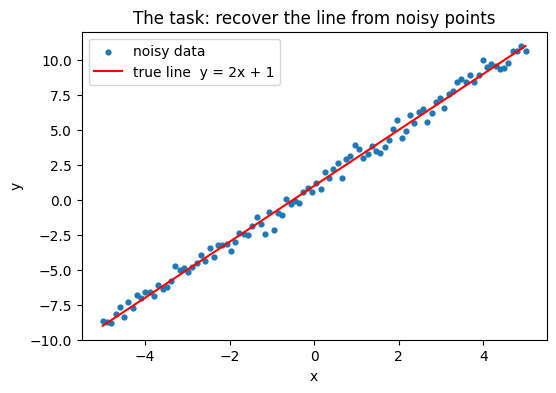

In [4]:
# --- Create a tiny synthetic dataset: y = 2x + 1 + noise ---

# 100 evenly spaced x values in [-5, 5], shaped as a column (100 rows, 1 feature).
X = torch.linspace(-5, 5, 100).reshape(-1, 1)

# True relationship is y = 2x + 1. We add small Gaussian noise so it's not *too* perfect,
# mimicking real data where measurements are never exact.
TRUE_W, TRUE_B = 2.0, 1.0
y = TRUE_W * X + TRUE_B + torch.randn_like(X) * 0.5

# Move data to the device (GPU/CPU).
X, y = X.to(device), y.to(device)

# Quick look at the data.
plt.figure(figsize=(6, 4))
plt.scatter(X.cpu(), y.cpu(), s=12, label="noisy data")
plt.plot(X.cpu(), (TRUE_W * X + TRUE_B).cpu(), 'r-', label="true line  y = 2x + 1")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("The task: recover the line from noisy points")
plt.show()

### The model: one neuron

`nn.Linear(1, 1)` **is** the neuron from Card 1: it holds one weight `w` and one bias `b`, and computes `w*x + b`. No activation here because the task is linear — this keeps the focus purely on the training loop. PyTorch initializes `w` and `b` to small random values; our job is to learn them.

In [5]:
# A single linear neuron: 1 input feature -> 1 output. Holds parameters w and b.
model = nn.Linear(1, 1).to(device)

print("Before training (random init):")
print(f"  w = {model.weight.item():.3f}  (we want ~{TRUE_W})")
print(f"  b = {model.bias.item():.3f}  (we want ~{TRUE_B})")

Before training (random init):
  w = 0.480  (we want ~2.0)
  b = 0.842  (we want ~1.0)


### The training loop — written by hand

This is the heart of the lab. Read the four stages in order; they are the entire engine of deep learning, and every framework just automates these same steps:

1. **Forward pass** — run inputs through the model to get predictions.
2. **Compute loss** — measure wrongness with MSE (Card 2), written out by hand so it's not a black box.
3. **Backward pass** — `loss.backward()` runs backprop (Card 3), filling each parameter's `.grad` with `∂loss/∂parameter` via the chain rule.
4. **Update** — nudge each parameter *downhill*: `p ← p − learning_rate × p.grad` (gradient descent).

The `zero_grad` step matters: PyTorch **accumulates** gradients by default, so we must clear last step's gradients before computing this step's, or they'd pile up.

In [6]:
learning_rate = 0.01
n_epochs = 200
loss_history = []   # we'll record the loss each epoch to plot the learning curve

for epoch in range(n_epochs):
    # 1) FORWARD PASS: predictions for every x.
    y_pred = model(X)

    # 2) LOSS: Mean Squared Error, written by hand = average of squared errors (Card 2).
    #    Squaring makes errors positive and punishes big misses harder.
    loss = ((y_pred - y) ** 2).mean()

    # 3) BACKWARD PASS:
    #    First clear old gradients (PyTorch accumulates them by default).
    model.zero_grad()
    #    Then backprop: this walks the chain rule backward and fills p.grad for every parameter.
    loss.backward()

    # 4) UPDATE (gradient descent), done manually so you see it explicitly.
    #    torch.no_grad(): we're editing weights, not building graph history for autograd.
    with torch.no_grad():
        for p in model.parameters():         # here: w, then b
            p -= learning_rate * p.grad       # step downhill, opposite the gradient

    loss_history.append(loss.item())

    # Print progress a few times so you can watch loss fall.
    if epoch % 40 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d} | loss {loss.item():8.4f} | "
              f"w {model.weight.item():.3f} | b {model.bias.item():.3f}")


epoch   0 | loss  19.8186 | w 0.738 | b 0.845
epoch  40 | loss   0.2013 | w 1.997 | b 0.941
epoch  80 | loss   0.1963 | w 1.998 | b 0.984
epoch 120 | loss   0.1953 | w 1.998 | b 1.003
epoch 160 | loss   0.1951 | w 1.998 | b 1.011
epoch 199 | loss   0.1951 | w 1.998 | b 1.015


### Did it work?

Two checks: the **loss curve** should fall and flatten, and the **learned** `w`, `b` should be close to the true 2 and 1. If both hold, you've just watched backprop + gradient descent recover a relationship from data — by hand.

After training:
  w = 1.998   (true 2.0)
  b = 1.015   (true 1.0)


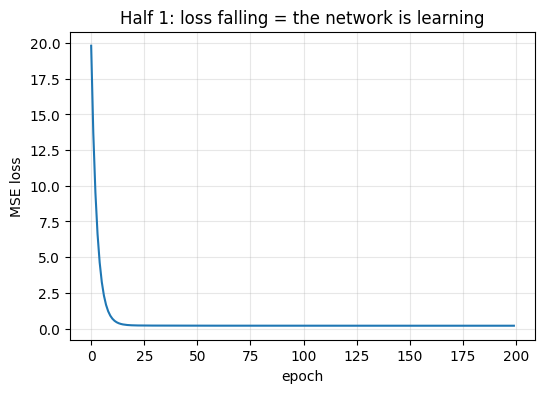

In [7]:
# Learned parameters vs. the truth.
print("After training:")
print(f"  w = {model.weight.item():.3f}   (true {TRUE_W})")
print(f"  b = {model.bias.item():.3f}   (true {TRUE_B})")

# The learning curve: loss should drop fast, then level off near zero.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("Half 1: loss falling = the network is learning")
plt.grid(True, alpha=0.3)
plt.show()

## HALF 2 — Expose the vanishing gradient

Now the important part. We build a **deep** network using `sigmoid` activations — the classic setup that suffers from vanishing gradients (Card 5). We do **one** forward+backward pass and record the **gradient norm of every layer**.

**What to expect:** the layers near the *output* get healthy gradients; the layers near the *input* get gradients so small they're effectively zero. The early layers are barely learning. We are not going to fix this here — **seeing it is the deliverable.** Group 2 is the fix.

In [8]:
# A deep stack of Linear + Sigmoid layers.
# Each Sigmoid's derivative is <= 0.25, and backprop MULTIPLIES these together layer by layer.
# Over many layers, that product shrinks toward zero for the earliest layers.
class DeepSigmoidNet(nn.Module):
    def __init__(self, depth=6, width=16):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Sigmoid()]      # input layer
        for _ in range(depth - 1):                        # hidden layers
            layers += [nn.Linear(width, width), nn.Sigmoid()]
        layers += [nn.Linear(width, 1)]                   # output layer (no activation)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

deep_model = DeepSigmoidNet(depth=6, width=16).to(device)
print(deep_model)


DeepSigmoidNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): Sigmoid()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): Sigmoid()
    (10): Linear(in_features=16, out_features=16, bias=True)
    (11): Sigmoid()
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)


### One forward + backward pass, then read the gradients

We don't even need to train. A single backward pass already reveals the gradient sizes across layers. We walk through the network, and for each `Linear` layer record `weight.grad.norm()` — a single number summarizing how strong that layer's learning signal is.

In [9]:
# Forward pass on our data, compute a loss, backprop once.
y_pred = deep_model(X)
loss = ((y_pred - y) ** 2).mean()
deep_model.zero_grad()
loss.backward()   # fills every layer's .grad — now we inspect them

# Collect the gradient norm of each Linear layer, in order from INPUT -> OUTPUT.
layer_names, grad_norms = [], []
idx = 0
for layer in deep_model.net:
    if isinstance(layer, nn.Linear):
        gn = layer.weight.grad.norm().item()   # one number: size of this layer's gradient
        grad_norms.append(gn)
        layer_names.append(f"Layer {idx}\n(Linear)")
        idx += 1

print("Gradient norm per layer (input -> output):")
for name, gn in zip(layer_names, grad_norms):
    print(f"  {name.replace(chr(10),' '):20s}: {gn:.8f}")

ratio = grad_norms[-1] / (grad_norms[0] + 1e-12)
print(f"\nThe OUTPUT layer's gradient is ~{ratio:,.0f}x larger than the INPUT layer's.")
print("=> The early layers are barely learning. That is the vanishing gradient.")


Gradient norm per layer (input -> output):
  Layer 0 (Linear)    : 0.00012384
  Layer 1 (Linear)    : 0.00054208
  Layer 2 (Linear)    : 0.00170103
  Layer 3 (Linear)    : 0.01168864
  Layer 4 (Linear)    : 0.09145675
  Layer 5 (Linear)    : 0.72842818
  Layer 6 (Linear)    : 5.40490294

The OUTPUT layer's gradient is ~43,645x larger than the INPUT layer's.
=> The early layers are barely learning. That is the vanishing gradient.


### The plot — this is the deliverable

A **log-scale** bar chart of gradient norm by layer. Log scale matters: the differences span several orders of magnitude, so on a linear axis the early bars would look like flat zero. The staircase climbing toward the output layer is the signature of the vanishing gradient.

Saved plot to: /content/drive/MyDrive/lab_a_vanishing_gradient.png


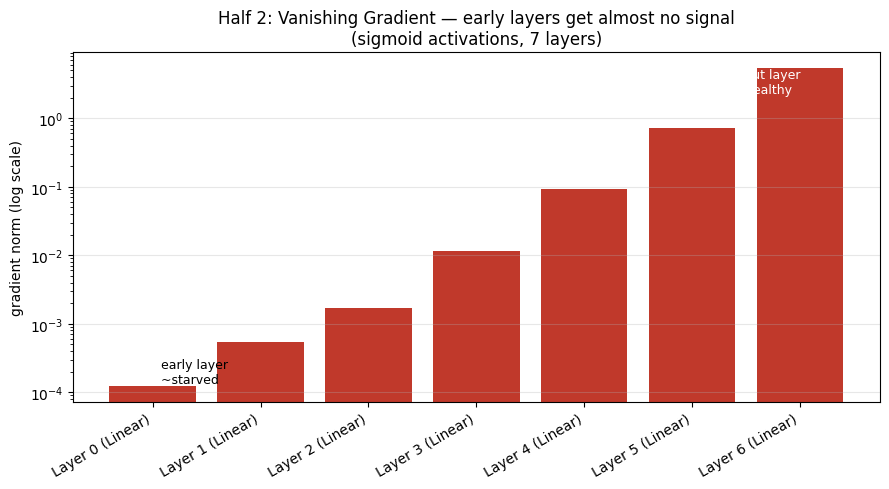

In [10]:
plt.figure(figsize=(9, 5))
bars = plt.bar(range(len(grad_norms)), grad_norms, color="#c0392b")
plt.yscale("log")   # crucial: spans many orders of magnitude
plt.xticks(range(len(grad_norms)), [n.replace(chr(10), " ") for n in layer_names], rotation=30, ha="right")
plt.ylabel("gradient norm (log scale)")
plt.title("Half 2: Vanishing Gradient — early layers get almost no signal\n(sigmoid activations, 7 layers)")
plt.grid(True, axis="y", alpha=0.3)

# Annotate the smallest (input) and largest (output) bars to make the contrast explicit.
plt.text(0, grad_norms[0], "  early layer\n  ~starved", va="bottom", fontsize=9)
plt.text(len(grad_norms)-1, grad_norms[-1], "output layer\nhealthy  ", va="top", ha="right", fontsize=9, color="white")

plt.tight_layout()
save_path = f"{SAVE_DIR}/lab_a_vanishing_gradient.png"
plt.savefig(save_path, dpi=120)
print("Saved plot to:", save_path)
plt.show()


## What you just proved

**Half 1.** You wrote the training loop by hand — forward, loss, backward, update — and watched a network recover `y = 2x + 1` from noisy data. Backprop is now a concrete procedure you've seen work, not a black box.

**Half 2.** You built a deep sigmoid network and *measured* the gradient at every layer. The early layers' gradients were smaller by orders of magnitude — they were starved of the learning signal. **That is the vanishing gradient problem (Card 5), seen with your own eyes.**

### The bridge to Group 2

Every tool in Group 2 exists to stop this gradient from collapsing:

- **ReLU/SELU activations** — derivatives that don't shrink the signal like sigmoid does
- **He/Xavier initialization** — keep signal variance stable from layer to layer
- **Batch normalization** — keep activations out of the saturated zone

When we start Group 2, the very first thing we'll do is swap sigmoid → ReLU in *this exact network* and re-plot these bars. You'll see them straighten out. That's the payoff of exposing the problem first.

